Fase 3: Visualización
Usando las herramientas de visualización que has aprendido durante este módulo, contesta a las siguientes preguntas usando la mejor gráfica que consideres:

- ¿Cómo se distribuye la cantidad de vuelos reservados por mes durante el año? 
- ¿Existe una relación entre la distancia de los vuelos y los puntos acumulados por los cliente? -- analisis de variables, ver categoria y elegir tipo de gráfico
- ¿Cuál es la distribución de los clientes por provincia o estado?
- ¿Cómo se compara el salario promedio entre los diferentes niveles educativos de los clientes? - promedio
- ¿Cuál es la proporción de clientes con diferentes tipos de tarjetas de fidelidad? -proporcion -porcentaje
- ¿Cómo se distribuyen los clientes según su estado civil y género?

En todos los ejercicios, no te quedes solo con la representación visual: añade siempre una breve interpretación en lenguaje natural, como lo haría un analista al presentar resultados a un equipo no técnico

In [1]:
import pandas as pd
import numpy as np
pd.set_option("display.max_columns", None)
import seaborn as sns
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)

In [2]:
df_unido = pd.read_csv("documentos_unidos.csv")

In [3]:
df_unido.sample(5)

,loyalty_number,country,province,city,postal_code,gender,education,salary,marital_status,loyalty_card,clv,enrollment_type,enrollment_year,enrollment_month,cancellation_year,cancellation_month,is_active,year,month,flights_booked,flights_with_companions,total_flights,distance,points_accumulated,points_redeemed,dollar_cost_points_redeemed
84502,289133,Canada,Ontario,Trenton,K8V 4B2,Male,Bachelor,89017.0,Divorced,Nova,14230.32,Standard,2013,9,Activo,Activo,1,2018,2,0,0,0,0,0.0,0.0,0
117573,363774,Canada,Alberta,Edmonton,T3G 6Y6,Female,Bachelor,73689.0,Single,Star,2613.02,Standard,2013,5,Activo,Activo,1,2018,12,11,0,11,3652,365.0,0.0,0
39309,188470,Canada,British Columbia,Victoria,V10 6T5,Male,Bachelor,73135.0,Single,Star,2674.73,Standard,2015,10,2017,12,0,2017,8,0,0,0,0,0.0,0.0,0
27320,161780,Canada,Quebec,Montreal,H3T 8L4,Male,Bachelor,59567.0,Divorced,Nova,4424.58,2018 Promotion,2018,4,Activo,Activo,1,2017,9,0,0,0,0,0.0,0.0,0
319057,809016,Canada,Ontario,Trenton,K8V 4B2,Male,Bachelor,90707.0,Divorced,Star,4815.53,Standard,2015,10,Activo,Activo,1,2018,9,4,0,4,364,36.0,0.0,0


1. ¿Cómo se distribuye la cantidad de vuelos reservados por mes durante el año?

In [4]:
# vuelos reservados por mes
reserva_vuelos_mes = df_unido.groupby(["year", "month"])["flights_booked"].sum().reset_index()
reserva_vuelos_mes

,year,month,flights_booked
0,2017,1,47766
1,2017,2,47691
2,2017,3,64271
3,2017,4,55720
4,2017,5,65279
5,2017,6,80493
6,2017,7,89288
7,2017,8,78692
8,2017,9,63304
9,2017,10,60351


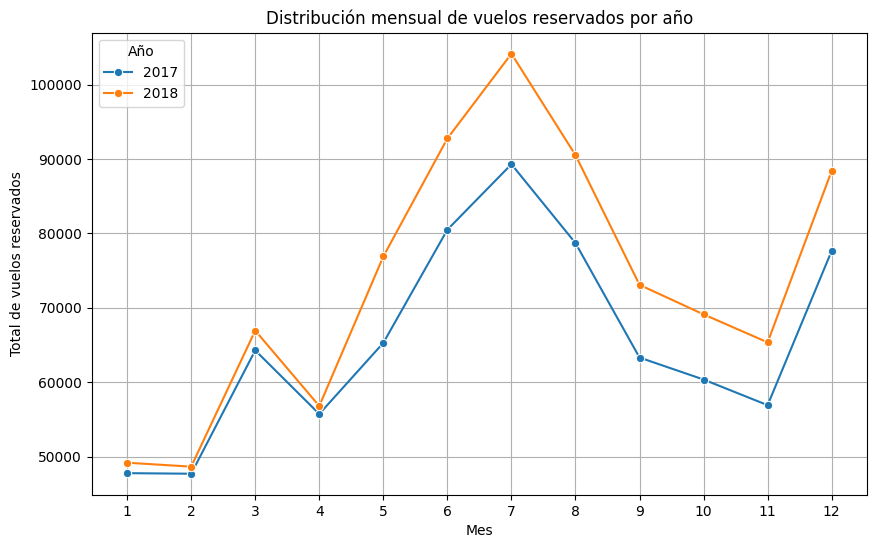

In [5]:

plt.figure(figsize=(10,6))
sns.lineplot(
    data=reserva_vuelos_mes,
    x="month",
    y="flights_booked",
    hue="year",
    marker="o",
    palette="tab10"  # paleta categórica estándar con colores contrastantes
)

plt.title("Distribución mensual de vuelos reservados por año")
plt.xlabel("Mes")
plt.ylabel("Total de vuelos reservados")
plt.xticks(range(1,13))
plt.grid(True)
plt.legend(title="Año", loc="upper left")  

plt.show()

Se observa un crecimiento uniforme del patrón de la reserva de vuelos en 2018 respecto a 2017. Sin cambios drásticos.
La distribución mensual es similar en los dos años, con subidas que empiezan en primavera. Abril decreció los dos años, pero después viene el repunte hasta julio, 
donde se alcanza el pico de reservas coincidiendo con el periodo vacacional general.
Desciende desde agosto hasta Noviembre, donde empieza el repunte debido, seguramente, a las vacaciones de navidad y fin de año.



2. ¿Existe una relación entre la distancia de los vuelos y los puntos acumulados por los cliente? 

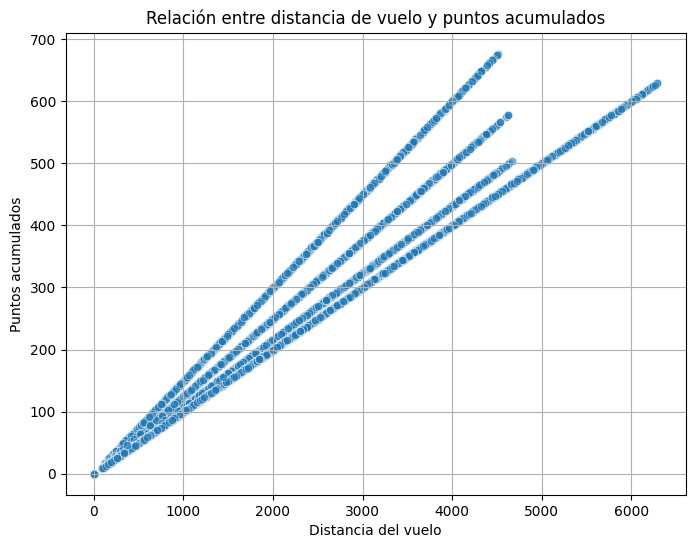

In [6]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df_unido, x="distance", y="points_accumulated", alpha=0.6)

plt.title("Relación entre distancia de vuelo y puntos acumulados")
plt.xlabel("Distancia del vuelo")
plt.ylabel("Puntos acumulados")
plt.grid(True)
plt.show()

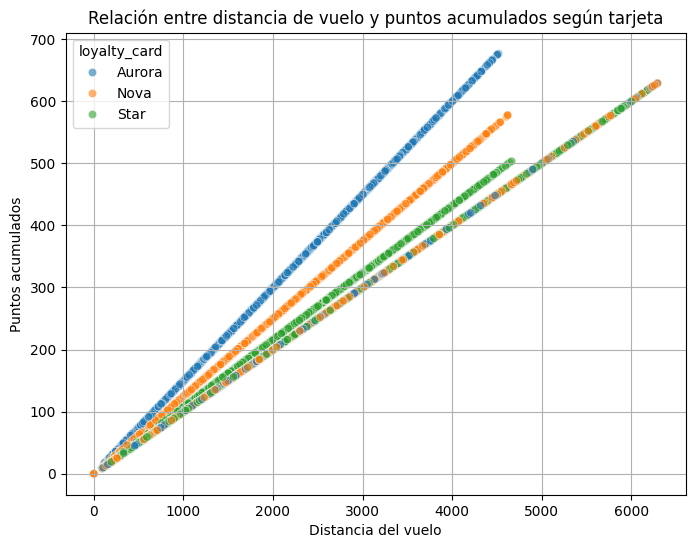

In [7]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df_unido, 
    x="distance", 
    y="points_accumulated", 
    hue="loyalty_card",  # colorea por categoría
    alpha=0.6
)
plt.title("Relación entre distancia de vuelo y puntos acumulados según tarjeta")
plt.xlabel("Distancia del vuelo")
plt.ylabel("Puntos acumulados")
plt.grid(True)
plt.show()

La relación entre distancia de vuelos y puntos acumulados es lineal, directa y positiva, y se ve diferenciada dependiendo del tipo de tarjeta de fidelidad.
Entiendo que cada tarjeta aplica una tasa diferente de puntos por kilómetro

In [8]:
df_unido.head()

,loyalty_number,country,province,city,postal_code,gender,education,salary,marital_status,loyalty_card,clv,enrollment_type,enrollment_year,enrollment_month,cancellation_year,cancellation_month,is_active,year,month,flights_booked,flights_with_companions,total_flights,distance,points_accumulated,points_redeemed,dollar_cost_points_redeemed
0,100018,Canada,Alberta,Edmonton,T9G 1W3,Female,Bachelor,92552.0,Married,Aurora,7919.2,Standard,2016,8,Activo,Activo,1,2017,1,3,0,3,1521,152.0,0.0,0
1,100018,Canada,Alberta,Edmonton,T9G 1W3,Female,Bachelor,92552.0,Married,Aurora,7919.2,Standard,2016,8,Activo,Activo,1,2017,2,2,2,4,1320,132.0,0.0,0
2,100018,Canada,Alberta,Edmonton,T9G 1W3,Female,Bachelor,92552.0,Married,Aurora,7919.2,Standard,2016,8,Activo,Activo,1,2018,10,6,4,10,3110,311.0,385.0,31
3,100018,Canada,Alberta,Edmonton,T9G 1W3,Female,Bachelor,92552.0,Married,Aurora,7919.2,Standard,2016,8,Activo,Activo,1,2017,4,4,0,4,924,92.0,0.0,0
4,100018,Canada,Alberta,Edmonton,T9G 1W3,Female,Bachelor,92552.0,Married,Aurora,7919.2,Standard,2016,8,Activo,Activo,1,2017,5,0,0,0,0,0.0,0.0,0


3. ¿Cuál es la distribución de los clientes por provincia o estado?


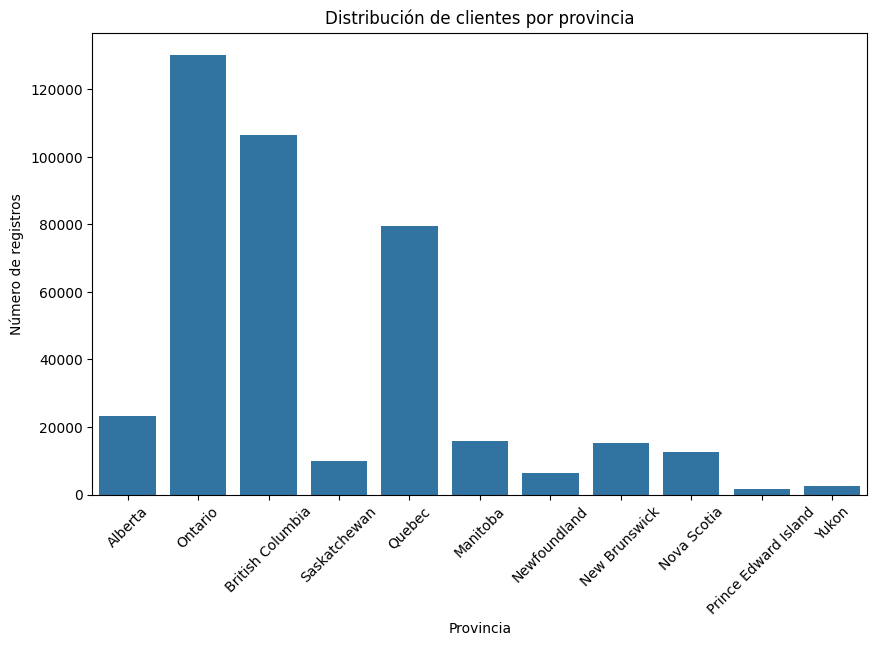

In [9]:
plt.figure(figsize=(10,6))
sns.countplot(data=df_unido, x='province')
plt.title("Distribución de clientes por provincia")
plt.xlabel("Provincia")
plt.ylabel("Número de registros")
plt.xticks(rotation=45)
plt.show()

Es coherente que Ontario, British Columbia y Quebec lideren el número de registros, ya que son las provincias con mayor población y concentran los principales aeropuertos del país. 
Cuentan con más rutas y conexiones, y lo que incrementa el volumen de vuelos y, en consecuencia, el número de clientes registrados en el dataset.
También son ls ciudades con más habitantes, seguidas de Alberta..
El resto de provincias presentan, en comparacion, una frecuencia muy baja, con valores que aportan poca variación a la distribución general.

4. ¿Cómo se compara el salario promedio entre los diferentes niveles educativos de los clientes? 


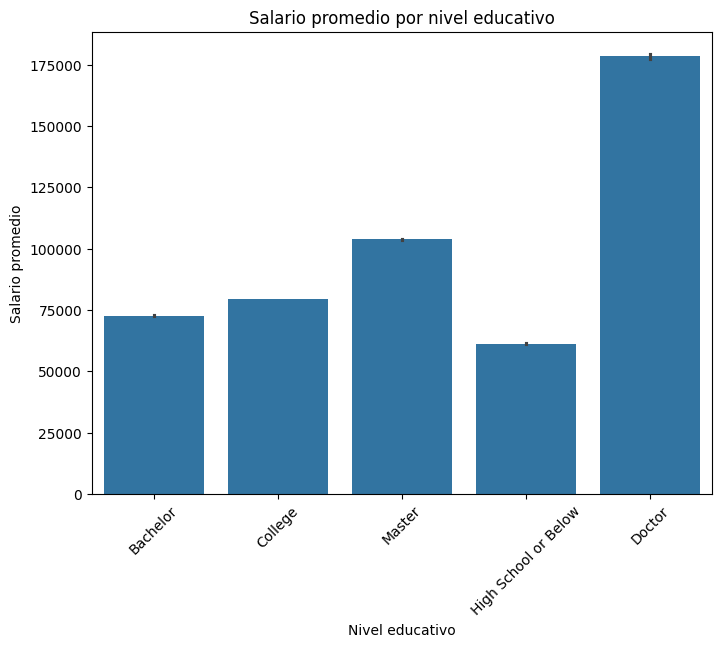

In [10]:
plt.figure(figsize=(8,6))
sns.barplot(data=df_unido, x="education", y="salary", estimator=np.mean)
plt.title("Salario promedio por nivel educativo")
plt.xlabel("Nivel educativo")
plt.ylabel("Salario promedio")
plt.xticks(rotation=45)
plt.show()

In [11]:
print(df_unido['education'].unique())

['Bachelor' 'College' 'Master' 'High School or Below' 'Doctor']


El gráfico muestra una tendencia clara: los clientes con niveles educativos más altos tienden a tener un salario promedio mayor. 
Esto sugiere que existe una relación positiva entre nivel educativo y salario promedio

5. ¿Cuál es la proporción de clientes con diferentes tipos de tarjetas de fidelidad?

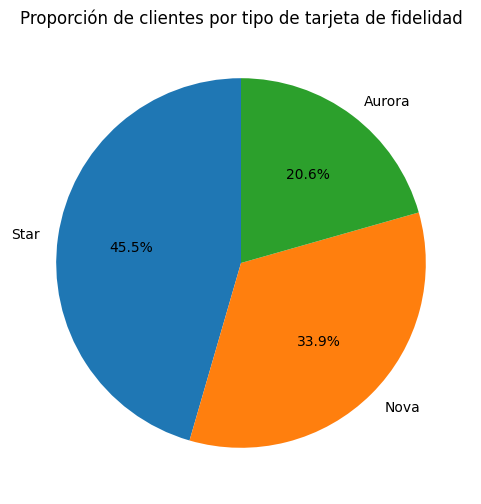

In [12]:
# Contar los clientes por tipo de tarjeta
counts = df_unido['loyalty_card'].value_counts()

# Crear pieplot: elegido pieplot porque solo hay 3 tipos de tarjeta. más visual creo
plt.figure(figsize=(6,6))
plt.pie(
    counts,
    labels=counts.index,
    autopct='%1.1f%%',   # porcentaje con un decimal
    startangle=90,        # rota el gráfico para que empiece en vertical
    colors=['#1f77b4','#ff7f0e','#2ca02c']  # colores visibles
)
plt.title("Proporción de clientes por tipo de tarjeta de fidelidad")
plt.show()

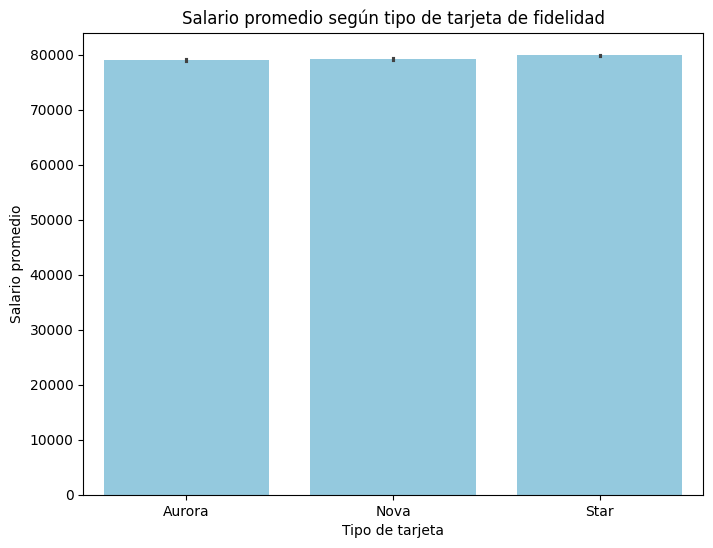

In [13]:

plt.figure(figsize=(8,6))
sns.barplot(
    data=df_unido,
    x='loyalty_card',
    y='salary',
    estimator=np.mean,
    color='skyblue'  # mismo color en todas las barras
)
plt.title("Salario promedio según tipo de tarjeta de fidelidad")
plt.xlabel("Tipo de tarjeta")
plt.ylabel("Salario promedio")
plt.show()

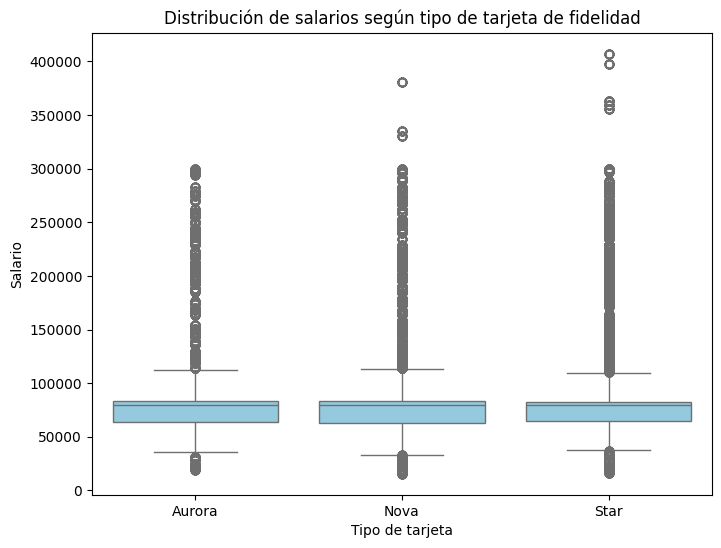

In [14]:

plt.figure(figsize=(8,6))
sns.boxplot(
    data=df_unido,
    x='loyalty_card',
    y='salary',
    color='skyblue'
)
plt.title("Distribución de salarios según tipo de tarjeta de fidelidad")
plt.xlabel("Tipo de tarjeta")
plt.ylabel("Salario")
plt.show()

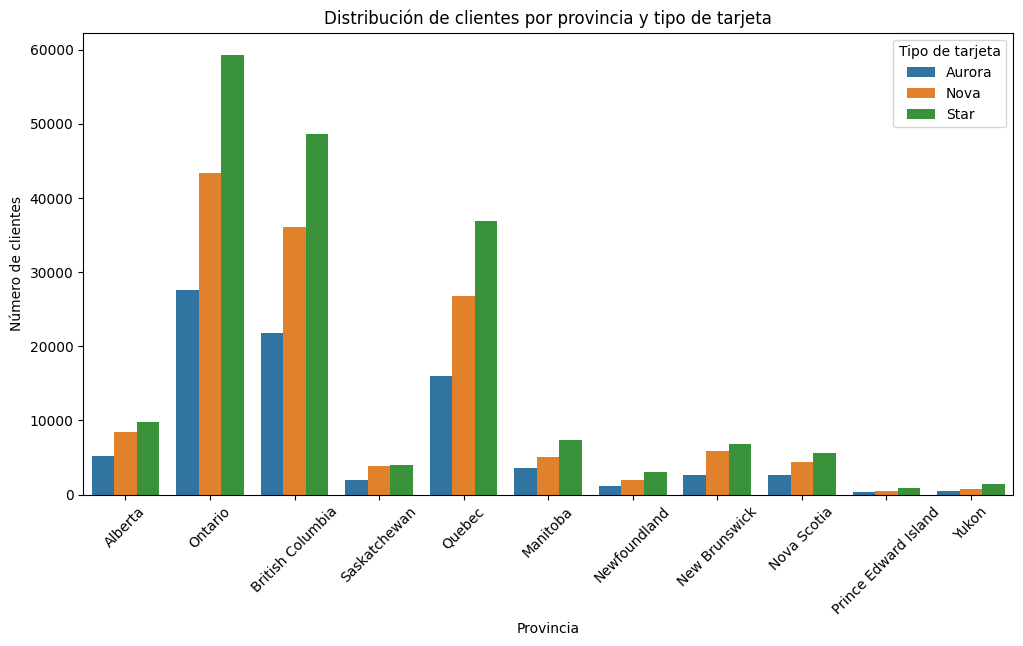

In [15]:
plt.figure(figsize=(12,6))
sns.countplot(
    data=df_unido,
    x='province',
    hue='loyalty_card'
)
plt.title("Distribución de clientes por provincia y tipo de tarjeta")
plt.xlabel("Provincia")
plt.ylabel("Número de clientes")
plt.xticks(rotation=45)
plt.legend(title="Tipo de tarjeta")
plt.show()

La proporción de clientes por tipo de tarjeta de fidelidad es la siguiente: Star, casi el 50%; seguida de Nova y Aurora. Esto tiene sentido porque, como vimos en una pregutna anterior, Star es la tarjeta que acumula más puntos.

He comprobado si los usuarios con tarjeta Star tenían un salario promedio más alto que los de las otras tarjetas, pero no es así: su salario promedio no es significativamente mayor.

También he analizado de qué provincias provienen los usuarios de cada tipo de tarjeta, para ver si esto podría aportar información relevante. Sin embargo, en todas las provincias la distribución de tipos de tarjeta sigue el mismo patrón que en el total de clientes: Star sigue siendo la más común, seguida de Nova y Aurora.

6. ¿Cómo se distribuyen los clientes según su estado civil y género?

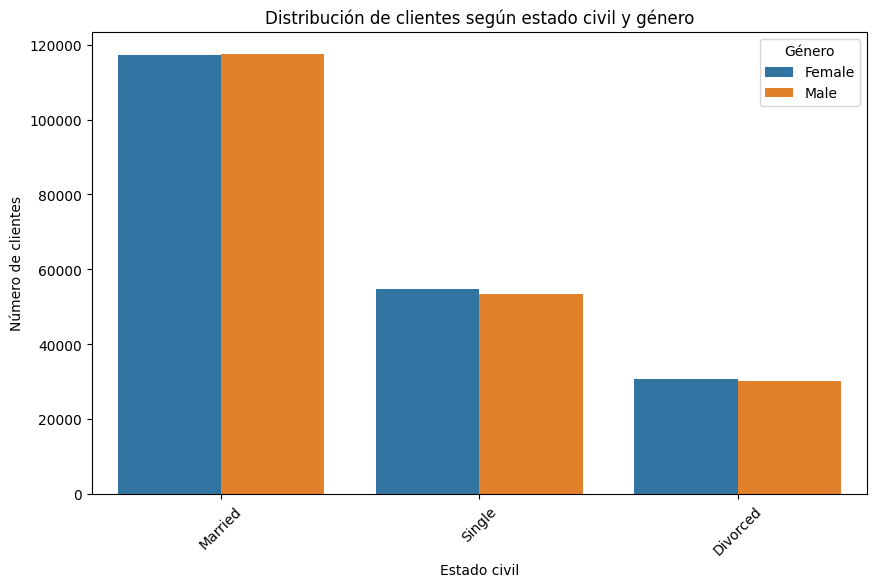

In [16]:
plt.figure(figsize=(10,6))
sns.countplot(
    data=df_unido,
    x='marital_status',
    hue='gender'
)
plt.title("Distribución de clientes según estado civil y género")
plt.xlabel("Estado civil")
plt.ylabel("Número de clientes")
plt.xticks(rotation=45)
plt.legend(title="Género")
plt.show()

La mayoría de los clientes son casados, con un número equilibrado de hombres y mujeres. Les siguen los solteros, aproximadamente la mitad que los casados, también con distribución de género similar, y los divorciados, que representan cerca de una cuarta parte de los casados, manteniendo igualmente la proporción entre hombres y mujeres.

En general, la distribución de género dentro de cada estado civil está equilibrada, sin sesgos significativos.

---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

Fase 4: Evaluación de Diferencias en Reservas de Vuelos por Nivel Educativo

Utilizando un conjunto de datos que hemos compartido, se busca evaluar si existen diferencias significativas en el número de vuelos reservados según el nivel educativo de los clientes. P
ara ello, los pasos que deberás seguir son:

- Preparación de Datos: Filtra el conjunto de datos para incluir únicamente las columnas relevantes: 'Flights Booked' y 'Education'.
- Análisis Descriptivo: Agrupa los datos por nivel educativo y calcula estadísticas descriptivas básicas (como el promedio, la desviación estándar) del número de vuelos reservados para cada grupo.

--- sacar las medidas descriptivas en reservas de vuelos, de cuantos vuelos reserva cada cleinte, pero por grupos por nvel educativo(media, mediana, cmite de variacion, rango...)
podemos ver si hay mas variacion en un grupo o en otro, si la media es mal alta en un grupo o en otro...

In [22]:

# Paso 1: Preparación de datos
df_vuelos = df_unido[['flights_booked', 'education']].copy()

# Función para calcular coeficiente de variación
def coef_var(x):
    return np.std(x, ddof=1) / np.mean(x) if np.mean(x) != 0 else np.nan

# Paso 2: Agrupar por nivel educativo y calcular estadísticas descriptivas
resumen_vuelos = df_vuelos.groupby('education')['flights_booked'].agg(
    count='count',
    mean='mean',
    median='median',
    std='std',
    coef_var=coef_var,
    min='min',
    max='max',
    range=lambda x: x.max() - x.min()
).reset_index()

resumen_vuelos

,education,count,mean,median,std,coef_var,min,max,range
0,Bachelor,252567,4.110288,1.0,5.221671,1.270391,0,21,21
1,College,102260,4.169744,1.0,5.246040,1.258121,0,21,21
2,Doctor,17731,4.175512,1.0,5.256971,1.259000,0,21,21
3,High School or Below,18915,4.176209,1.0,5.239267,1.254551,0,21,21
4,Master,12287,4.200700,1.0,5.213956,1.241211,0,21,21
